# Lab 4: Handling Imbalanced Datasets using SMOTE
### CS2227: Artificial Intelligence and Machine Learning

---

## Objective
In this lab, we tackle one of the most common real world problems in machine learning: **class imbalance**.
When one class vastly outnumbers another (e.g., 90% legitimate vs 10% fraud), standard classifiers are
biased toward the majority class, leading to the **Accuracy Paradox**.

We use **SMOTE (Synthetic Minority Oversampling Technique)** to synthesize new minority samples
via **linear interpolation** between existing minority points, avoiding both overfitting (from duplication)
and information loss (from undersampling).

---

## Mathematical Intuition: How SMOTE Works

SMOTE generates a new synthetic point between two existing minority class points:

$$\text{New Point} = A + \lambda \cdot (B - A)$$

Where:
- $A$ = a minority sample
- $B$ = one of its $k$-nearest minority neighbors
- $\lambda \in [0, 1]$ = a random weight

**Worked Example:**
- Point A = (2, 3), Point B = (4, 7), λ = 0.5
- Difference = (4−2, 7−3) = (2, 4)
- Scaled = 0.5 × (2, 4) = (1, 2)
- New Point = (2, 3) + (1, 2) = **(3, 5)**

> **Critical Rule:** Always apply SMOTE **after** the train/test split. Applying it before causes **data leakage** — synthetic points influenced by test data bleed into training, inflating performance metrics artificially.

---
## Step 1: Install Required Library
We use `imbalanced-learn`, which integrates seamlessly with `scikit-learn`.

In [1]:
!pip install imbalanced-learn -q

---
## Step 2: Setup and Data Generation

We generate a **synthetic imbalanced dataset** with:
- 1000 samples
- 2 features (for easy 2D visualization)
- 90% Class 0 (majority) and 10% Class 1 (minority)

This simulates a real-world scenario like rare disease detection or fraud.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from collections import Counter

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.90],
    random_state=42
)

print(f"Original class distribution: {Counter(y)}")
print(f"  Class 0 (majority): {Counter(y)[0]} samples ({Counter(y)[0]/len(y)*100:.1f}%)")
print(f"  Class 1 (minority): {Counter(y)[1]} samples ({Counter(y)[1]/len(y)*100:.1f}%)")

Original class distribution: Counter({np.int64(0): 896, np.int64(1): 104})
  Class 0 (majority): 896 samples (89.6%)
  Class 1 (minority): 104 samples (10.4%)


---
## Step 3: Applying SMOTE

We initialize SMOTE with:
- `sampling_strategy='minority'` → upsample the minority class to match the majority
- `k_neighbors=5` → each synthetic point is generated using 5 nearest minority neighbors
- `random_state=42` → ensures reproducibility

In [3]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='minority',
    random_state=42,
    k_neighbors=5
)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled class distribution: {Counter(y_resampled)}")
print(f"  Class 0 (majority): {Counter(y_resampled)[0]} samples")
print(f"  Class 1 (minority): {Counter(y_resampled)[1]} samples  ← synthetically increased")
print(f"\nTotal new samples added: {len(X_resampled) - len(X)}")

Resampled class distribution: Counter({np.int64(0): 896, np.int64(1): 896})
  Class 0 (majority): 896 samples
  Class 1 (minority): 896 samples  ← synthetically increased

Total new samples added: 792


---
## Step 4: Visualization — Before vs After SMOTE

The scatter plots below show how SMOTE fills in the minority class region with **interpolated** points
(not duplicates). Notice how the minority cluster becomes much denser after resampling.

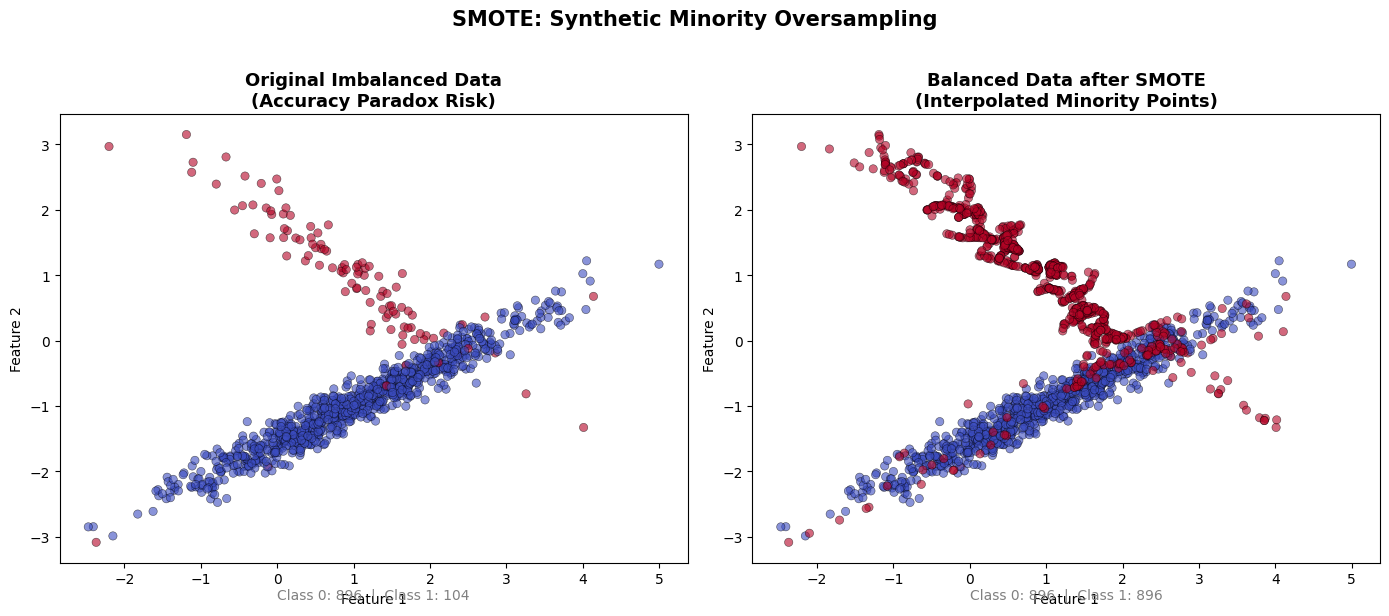


Observation: The minority class (red/warm) region is now much denser due to SMOTE interpolation.
These are NOT duplicates — they are NEW synthetic points placed between existing minority samples.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(
    X[:, 0], X[:, 1],
    c=y,
    alpha=0.6,
    cmap='coolwarm',
    edgecolors='k',
    linewidths=0.4
)
ax1.set_title("Original Imbalanced Data\n(Accuracy Paradox Risk)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

ax1.annotate(f"Class 0: {Counter(y)[0]}  |  Class 1: {Counter(y)[1]}",
             xy=(0.5, -0.08), xycoords='axes fraction', ha='center', fontsize=10, color='gray')

ax2.scatter(
    X_resampled[:, 0], X_resampled[:, 1],
    c=y_resampled,
    alpha=0.6,
    cmap='coolwarm',
    edgecolors='k',
    linewidths=0.4
)
ax2.set_title("Balanced Data after SMOTE\n(Interpolated Minority Points)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")
ax2.annotate(f"Class 0: {Counter(y_resampled)[0]}  |  Class 1: {Counter(y_resampled)[1]}",
             xy=(0.5, -0.08), xycoords='axes fraction', ha='center', fontsize=10, color='gray')

plt.suptitle("SMOTE: Synthetic Minority Oversampling", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nObservation: The minority class (red/warm) region is now much denser due to SMOTE interpolation.")
print("These are NOT duplicates — they are NEW synthetic points placed between existing minority samples.")

---
## Summary

| Step | What Happened |
|------|---------------|
| Data Generation | 1000 samples, 90/10 imbalance |
| SMOTE Applied | Minority class oversampled via interpolation |
| Result | Balanced dataset (equal class counts) |

**Key Takeaway:** SMOTE generates realistic minority points by interpolating between real ones,
not just copying them. This prevents overfitting while correcting class imbalance.